--- Dataset Analysis ---
Cluster Distribution:
cluster
2    91
0    59
1    32
Name: count, dtype: int64

--- Random Forest Regressor Metrics ---
RMSE (Root Mean Squared Error): 0.4870
MAE (Mean Absolute Error): 0.3551
R2 Score (Variance Explained): 0.3167

--- Gradient Boosting Regressor Metrics ---
RMSE (Root Mean Squared Error): 0.5273
MAE (Mean Absolute Error): 0.3827
R2 Score (Variance Explained): 0.1989



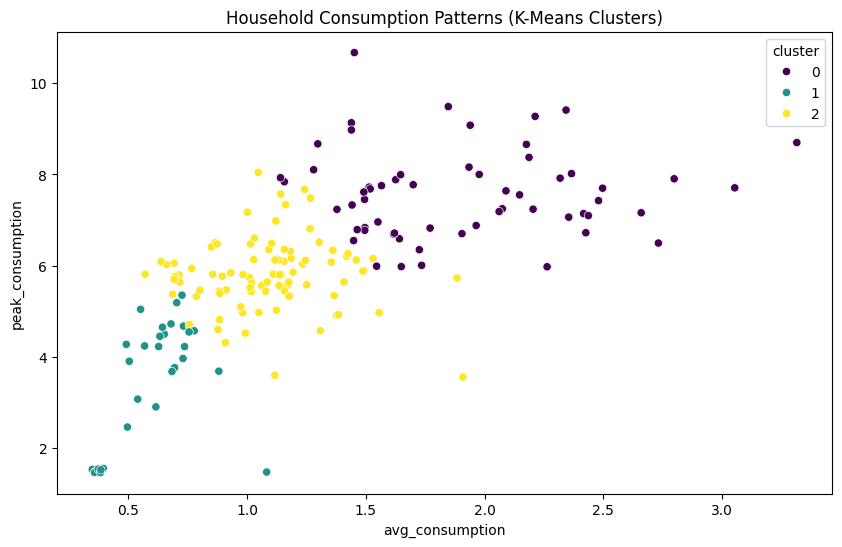

--- Future Forecast Results ---
Current Cluster: 2
Random Forest Prediction: 1.1323 kW
Gradient Boosting Prediction: 1.2041 kW


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split

# 1. Load and Preprocess data
# Fixing deprecated parse_dates and handling formatting warnings
df = pd.read_csv('household_power_consumption.txt', sep=';',
                 low_memory=False, na_values=['?'])

# Combine Date and Time correctly
df['datetime'] = pd.to_datetime(df['Date'] + ' ' + df['Time'], dayfirst=True)
df.set_index('datetime', inplace=True)
df.drop(['Date', 'Time'], axis=1, inplace=True)

# Drop missing values to ensure model stability
df.dropna(inplace=True)

# 2. Feature Extraction
# Extracting temporal patterns to improve prediction accuracy
df['hour'] = df.index.hour
df['day_of_week'] = df.index.dayofweek
df['month'] = df.index.month

# Resample to Daily: Calculate avg, peak (max), and variance
daily_df = df['Global_active_power'].resample('D').agg(['mean', 'max', 'std']).dropna()
daily_df.columns = ['avg_consumption', 'peak_consumption', 'variance']

# Map temporal features back to the daily dataframe
daily_df['day_of_week'] = df['day_of_week'].resample('D').first()
daily_df['month'] = df['month'].resample('D').first()

# 3. Unsupervised Clustering (K-Means) [cite: 7]
scaler = StandardScaler()
scaled_features = scaler.fit_transform(daily_df[['avg_consumption', 'peak_consumption', 'variance']])

# Grouping households/days with similar behavior [cite: 7]
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
daily_df['cluster'] = kmeans.fit_predict(scaled_features)

# 4. Train Supervised Models [cite: 9]
# Target: Predict the next day's average consumption [cite: 12]
daily_df['target'] = daily_df['avg_consumption'].shift(-1)
data_final = daily_df.dropna()

# Features include the cluster ID and temporal data [cite: 14]
X = data_final[['avg_consumption', 'peak_consumption', 'variance', 'cluster', 'day_of_week', 'month']]
y = data_final['target']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Model Initialization [cite: 10, 11]
models = {
    "Random Forest Regressor": RandomForestRegressor(n_estimators=100, random_state=42),
    "Gradient Boosting Regressor": GradientBoostingRegressor(random_state=42)
}

# 5. Evaluation and Output [cite: 13]
print(f"--- Dataset Analysis ---")
print(f"Cluster Distribution:\n{daily_df['cluster'].value_counts()}\n")

for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)

    rmse = np.sqrt(mean_squared_error(y_test, preds))
    mae = mean_absolute_error(y_test, preds)
    r2 = r2_score(y_test, preds)

    print(f"--- {name} Metrics ---")
    print(f"RMSE (Root Mean Squared Error): {rmse:.4f}")
    print(f"MAE (Mean Absolute Error): {mae:.4f}")
    print(f"R2 Score (Variance Explained): {r2:.4f}\n")

# Visualization of Clusters
plt.figure(figsize=(10, 6))
sns.scatterplot(data=daily_df, x='avg_consumption', y='peak_consumption', hue='cluster', palette='viridis')
plt.title('Household Consumption Patterns (K-Means Clusters)')
plt.show()

# 1. Update Features for the Model
X = data_final[['avg_consumption', 'peak_consumption', 'variance', 'cluster', 'day_of_week', 'month']]
y = data_final['target']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 2. Re-fit Models with the new features
rf_model.fit(X_train, y_train)
gb_model.fit(X_train, y_train)

# 3. Predict the Future for each cluster
latest_data = daily_df.tail(1)
features_to_predict = latest_data[['avg_consumption', 'peak_consumption', 'variance', 'cluster', 'day_of_week', 'month']]

rf_forecast = rf_model.predict(features_to_predict)
gb_forecast = gb_model.predict(features_to_predict)

current_cluster = latest_data['cluster'].values[0]

print(f"--- Future Forecast Results ---")
print(f"Current Cluster: {current_cluster}")
print(f"Random Forest Prediction: {rf_forecast[0]:.4f} kW")
print(f"Gradient Boosting Prediction: {gb_forecast[0]:.4f} kW")